Load a set of tiff with same xps value from directory, then average and manually draw out the data mask.

In [1]:
import sys
import os
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()
# Go up one level to project root (adjust based on your structure)
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

In [2]:
from pathlib import Path
from src.processor.expdir_processor import DirectoryProcessor
from src.processor.bkg_objects import CalcBackground
from src.processor.tiff_objects import EMCCDimage
from src.io.tiff_SL import load_tiff_single, save_as_tiff
from src.io.png_mask import data_to_color_png, bw_png_to_mask_ndarray
from src.plots.quick_plot import plot_ndarray

In [31]:
# Basic path settings
Bkgdata_folder = Path(r"E:\20251012\day1_uvoff_42deg_bkg\fist_AndorEMCCD")
Expdata_folder = Path(r"E:\20251011\5_longscan_42deg_uv62p4deg_1\fist_AndorEMCCD")
Result_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\1011long")

Processing background images from: E:\20251012\day1_uvoff_42deg_bkg\fist_AndorEMCCD
Found 100 TIFF files
Loaded 100 background images
Randomly sampled 50 files for X-ray statistics precomputation
Processing image 1/100 for X-ray removal...
Processing image 2/100 for X-ray removal...
Processing image 3/100 for X-ray removal...
Processing image 4/100 for X-ray removal...
Processing image 5/100 for X-ray removal...
Processing image 6/100 for X-ray removal...
Processing image 7/100 for X-ray removal...
Processing image 8/100 for X-ray removal...
Processing image 9/100 for X-ray removal...
Processing image 10/100 for X-ray removal...
Processing image 11/100 for X-ray removal...
Processing image 12/100 for X-ray removal...
Processing image 13/100 for X-ray removal...
Processing image 14/100 for X-ray removal...
Processing image 15/100 for X-ray removal...
Processing image 16/100 for X-ray removal...
Processing image 17/100 for X-ray removal...
Processing image 18/100 for X-ray removal...
Pro

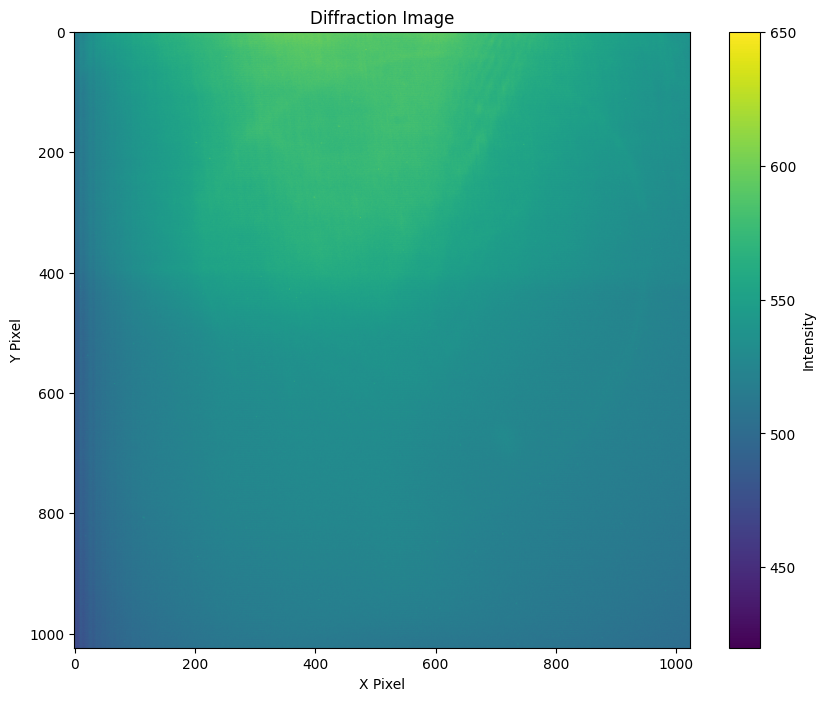

Successfully saved array to: C:\Users\ab177\Desktop\diffraction_results\1011long\background.tiff
  - Shape: (1024, 1024)
  - Data type: float64
  - File size: 8.00 MB
Loaded background from: E:\20251012\day1_uvoff_42deg_bkg\fist_AndorEMCCD


In [32]:
# Calculate and plot background
Bkgobj = CalcBackground(Bkgdata_folder)
Background = Bkgobj.process_background_Xray(sigma_threshold= 1500, expansion_threshold_ratio= 0.7, center_pos=[0,0,0])
plot_ndarray(Background, 420, 650)

# If multiple backgrounds were used:
#avgbkg = bkg1*coeff1 + bkg2*coeff2 ......
# Save background
save_as_tiff(Background, Result_folder, 'background', False)
print(f"Loaded background from: {Bkgdata_folder}")

In [6]:
# Check Xray removing parameters with data: (No Background Removel)
Testdata_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\Xraytest")
Testobj = CalcBackground(Testdata_folder)
# Warning! NO NOT RUN IT DIRECTLY ON Expdata_folder, Memory overflow
Xray = Testobj.process_background_choice(method="di")
Mean = Testobj.process_background_choice(method="mean")
NoXray = Testobj.process_background_Xray(sigma_threshold= 15, expansion_threshold_ratio= 0.7, center_pos=[0,0,0])

Processing background images from: C:\Users\ab177\Desktop\diffraction_results\Xraytest
Found 95 TIFF files
Loaded 95 background images
Computed crude median background - Shape: (1024, 1024), 
Processing background images from: C:\Users\ab177\Desktop\diffraction_results\Xraytest
Found 95 TIFF files
Loaded 95 background images
Computed crude median background - Shape: (1024, 1024), 
Processing background images from: C:\Users\ab177\Desktop\diffraction_results\Xraytest
Found 95 TIFF files
Loaded 95 background images
Randomly sampled 50 files for X-ray statistics precomputation
Processing image 1/95 for X-ray removal...
Processing image 2/95 for X-ray removal...
Processing image 3/95 for X-ray removal...
Processing image 4/95 for X-ray removal...
Processing image 5/95 for X-ray removal...
Processing image 6/95 for X-ray removal...
Processing image 7/95 for X-ray removal...
Processing image 8/95 for X-ray removal...
Processing image 9/95 for X-ray removal...
Processing image 10/95 for X-ray

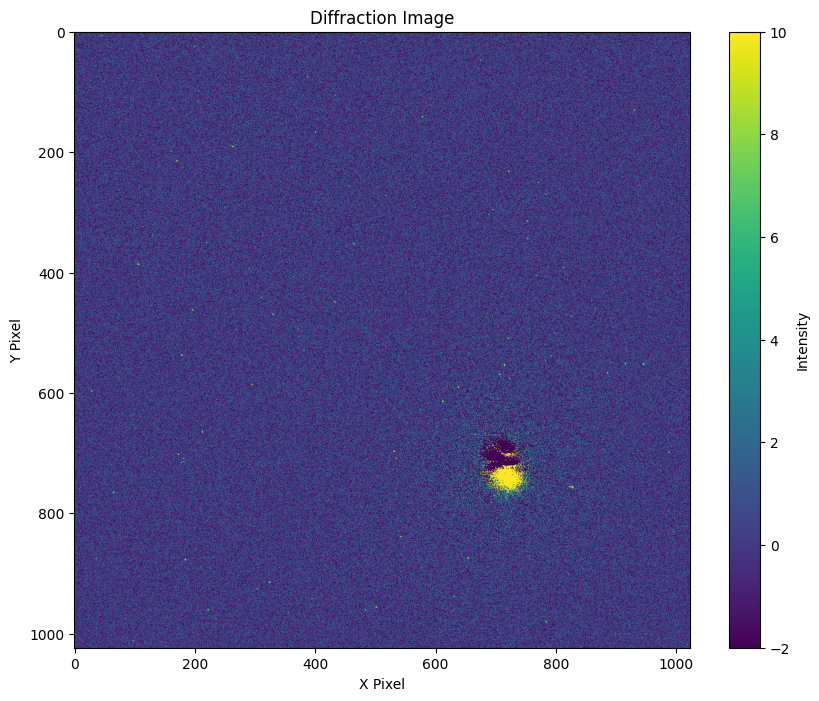

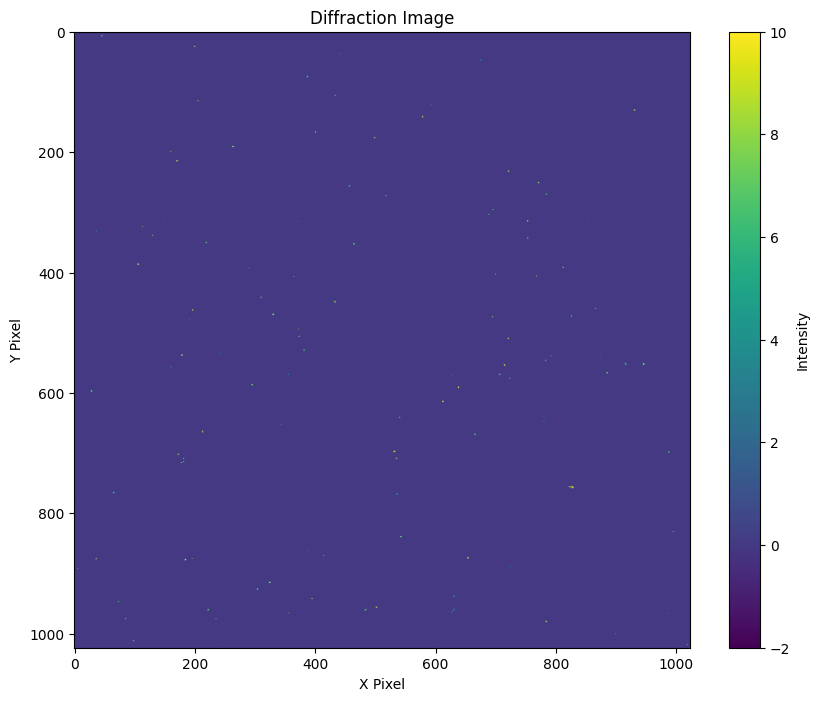

In [7]:
# Plotting Xray 
plot_ndarray(-Xray, -2, 10)
plot_ndarray(Mean-NoXray, -2, 10)

In [33]:
Preprocessor = DirectoryProcessor(
    result_directory= Result_folder,
    data_directory= Expdata_folder,
    xps_grouping_param= [],
    xray_removal_param= [15,0.7],
    center_fitting_param= [80,180,562,512],
    azimuthal_avg_param= [512,512],
    background_directory= "default",
    data_mask_directory= "default"
)

preprocess_data = Preprocessor.preprocess_screening(group_size=100)

2026-01-16 09:48:31,535 - INFO - Starting preprocess screening with 100 images
2026-01-16 09:48:31,535 - INFO - Initializing processing masks...


(562, 512)


2026-01-16 09:48:32,283 - INFO - Masks initialized successfully
2026-01-16 09:48:32,283 - INFO - Initializing background and data mask...
2026-01-16 09:48:32,289 - INFO - Loaded background from: C:\Users\ab177\Desktop\diffraction_results\1011long\background.tiff
2026-01-16 09:48:32,293 - INFO - Default data mask file not found under: C:\Users\ab177\Desktop\diffraction_results\1011long\background.tiff, proceed without masking!
2026-01-16 09:48:32,294 - INFO - Numbered test XPS group selection...



SELECT TEST XPS GROUP
 1. XPS 180.21250: 1590 files
 2. XPS 180.36250: 1590 files
 3. XPS 179.46250: 1580 files
 4. XPS 179.66500: 1580 files
 5. XPS 179.65750: 1570 files
 6. XPS 179.50750: 1540 files
 7. XPS 179.49250: 1500 files
 8. XPS 179.53750: 1480 files
 9. XPS 179.63500: 1480 files
10. XPS 179.56000: 1460 files
11. XPS 179.60375: 1440 files
12. XPS 179.61250: 1420 files
13. XPS 179.56750: 1410 files
14. XPS 179.59000: 1410 files
15. XPS 179.58125: 1380 files
16. XPS 179.64000: 1360 files
17. XPS 179.59500: 1340 files
18. XPS 179.61750: 1320 files
19. XPS 179.62625: 1300 files
20. XPS 179.67250: 1300 files
21. XPS 179.62125: 1270 files
22. XPS 179.65000: 1260 files
23. XPS 179.64375: 1250 files
24. XPS 179.58500: 1147 files
25. XPS 179.59875: 1090 files
26. XPS 179.52250: 1080 files
27. XPS 179.63000: 1050 files
28. XPS 179.57500: 1000 files
29. XPS 179.54500:  940 files
30. XPS 179.55250:  930 files
31. XPS 179.47625:  820 files
32. XPS 179.60750:  800 files
33. XPS 179.47750

2026-01-16 09:48:37,446 - INFO - Configuration saved to C:\Users\ab177\Desktop\diffraction_results\1011long\preprocessing_screening_config\config\config.csv
2026-01-16 09:48:37,449 - INFO - Preprocessing test group - computing mean of 100 images
2026-01-16 09:48:37,449 - INFO - Randomly sampled 50 files for X-ray statistics precomputation


✓ Selected group 1: XPS 180.21250 with 1590 files
Limited to 100 evenly spaced files (from 1590 total)


2026-01-16 09:48:40,366 - INFO - X-ray statistics precomputation completed. Center region (40x40) excluded.


✓ Mean image computed from 100 images


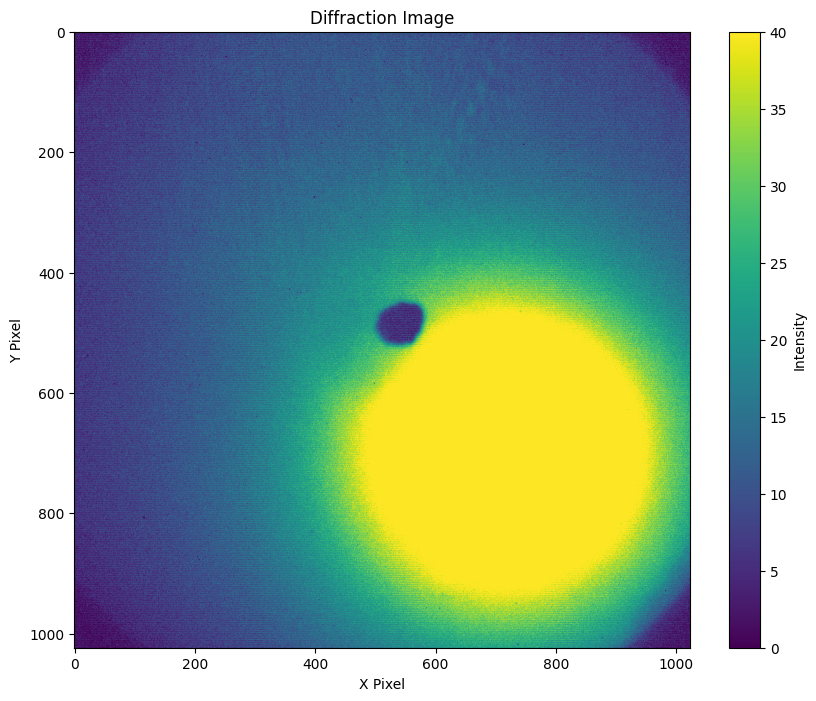

In [40]:
plot_ndarray(preprocess_data,0,40)

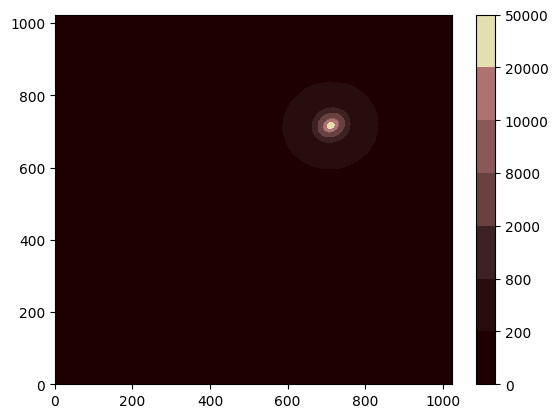

In [91]:
import matplotlib.pyplot as plt
import matplotlib as mpl

N = [0,200,800,2000,8000,10000,20000,50000]
CS = plt.contourf(preprocess_data,N,cmap='pink')
plt.colorbar(CS)
plt.show()

In [35]:
import numpy as np
masked_data = preprocess_data.copy()
# 1. Create coordinate grids for rows (y) and columns (x)
y, x = np.ogrid[:1024, :1024]
# 2. Define the two distance conditions (using squared distances for speed)
# Condition 1: Distance from (500, 550) > 600
mask1 = (x - 512)**2 + (y - 512)**2 > 600**2
# Condition 2: Distance from (510, 400) < 80
mask2 = (x - 550)**2 + (y - 500)**2 < 100**2
# 3. Apply the combined mask to set pixels to NaN
masked_data[mask1 | mask2] = np.nan

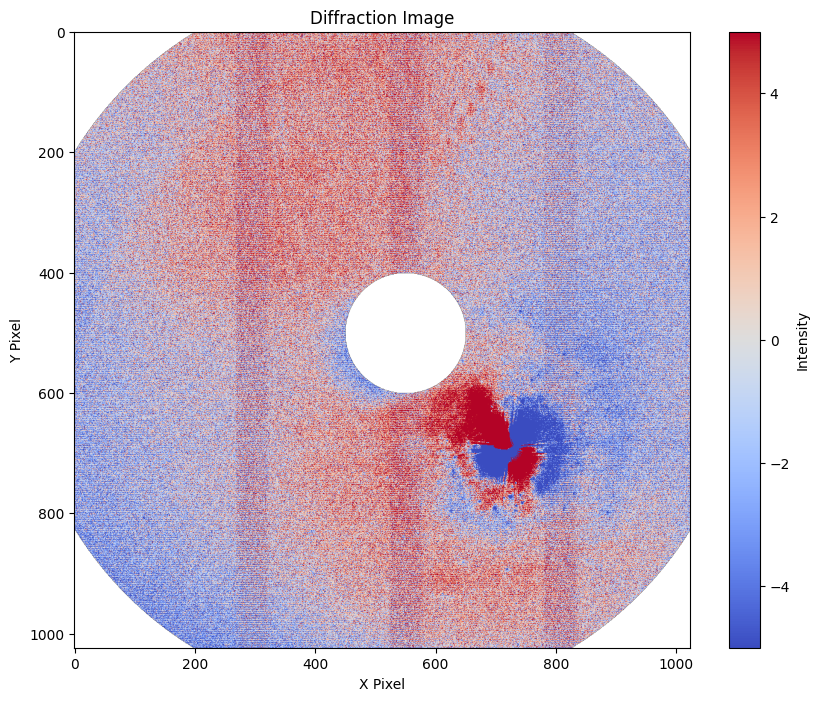

In [36]:
#plot_ndarray(masked_data,-20,50)
selected_mean = EMCCDimage(masked_data)
selected_mean.copy_as_processed()
selected_mean.center_pos = (721,692)
eccentric_dev = selected_mean.plot_radial_eccentricity()
plot_ndarray(-eccentric_dev, -5, 5, 'coolwarm')


C:\Users\ab177\AppData\Local\Temp\ipykernel_9504\1819869494.py:2: RuntimeWarning: divide by zero encountered in divide
  eccentric_dev = selected_mean.plot_radial_eccentricity() / preprocess_data


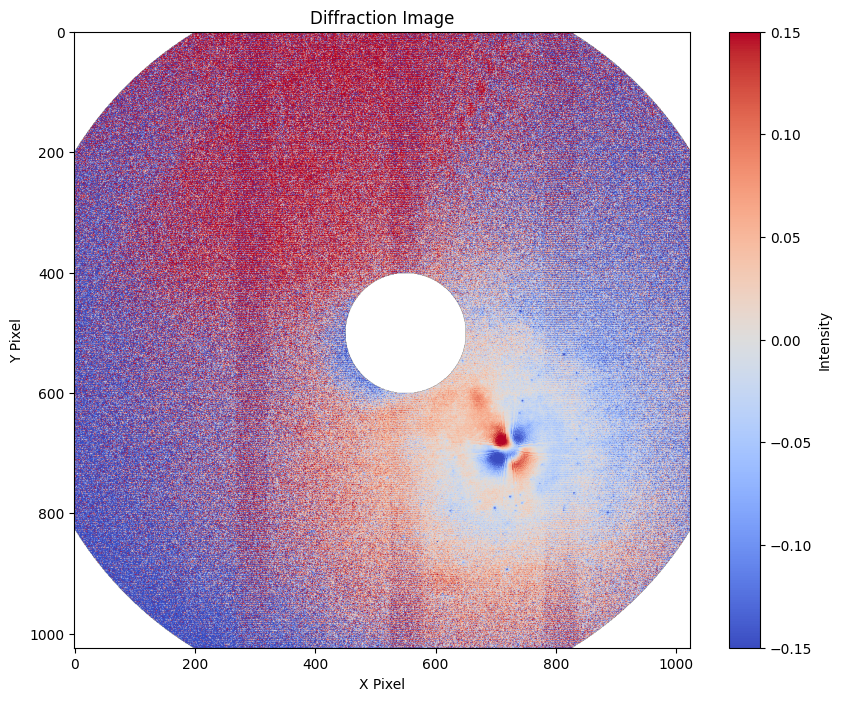

In [37]:
selected_mean.center_pos = (721,692)
eccentric_dev = selected_mean.plot_radial_eccentricity() / preprocess_data
plot_ndarray(-eccentric_dev, -0.15, 0.15, 'coolwarm')

In [41]:
png_path = Result_folder / 'preprocess_center.png'
data_to_color_png(data_array = preprocess_data, 
                  filename = png_path,
                  manual_min = 0,
                  manual_max= 40)

Generating color map image 'C:\Users\ab177\Desktop\diffraction_results\1011long\preprocess_center.png' using 'viridis'...
Successfully saved color-mapped image to C:\Users\ab177\Desktop\diffraction_results\1011long\preprocess_center.png


Loading mask image 'C:\Users\ab177\Desktop\diffraction_results\1013longccl4\preprocess_data_mask.png'...
Successfully converted mask to NumPy array of shape (1024, 1024) and dtype int64
Successfully saved array to: C:\Users\ab177\Desktop\diffraction_results\1013longccl4\data_mask.tiff
  - Shape: (1024, 1024)
  - Data type: int64
  - File size: 0.09 MB


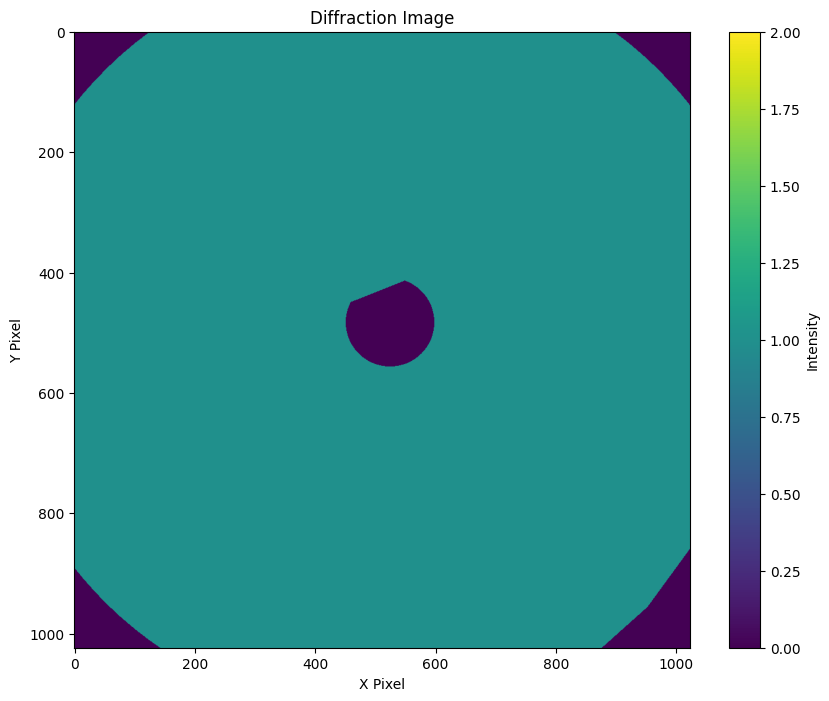

In [ ]:
#white in center, valid data
#data_mask ; background_mask
mask_path = Result_folder / 'preprocess_data_mask.png'
mask = bw_png_to_mask_ndarray(filename=mask_path)
save_as_tiff(mask, Result_folder, 'data_mask')
plot_ndarray(mask,0,2)